# Mohajer m vs NDCG@10 on TREC-COVID

Sweep the Mohajer ranker's `m` parameter and measure how it affects NDCG@10 on the TREC-COVID reranking matrix. All runs reuse the same seed and cached data so only the sampling budget controlled by `m` is changing.


In [1]:
from typing import Sequence

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ireranker.data.loaders import load_beir_dataset
from ireranker.evaluation.beir import evaluate_rankers_beir
from ireranker.rankers import get_ranker

plt.style.use('ggplot')


2025-11-25 18:07:48.063 | INFO     | ireranker.config:<module>:14 - PROJ_ROOT path is: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker


In [2]:
DATASET = 'fiqa'
SEEDS = [1, 2, 3]
K_VALUES = [10]
M_VALUES = np.linspace(1, 2, 10)

dataset = load_beir_dataset(DATASET, split='test')
print(f'Loaded {DATASET} with {len(dataset.tasks)} queries.')
print(f'Running {len(SEEDS)} seeds: {SEEDS}')


/home/jerefigo/.local/lib/python3.10/site-packages/beir/util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


2025-11-25 18:07:49.617 | INFO     | ireranker.data.loaders:_download_beir_once:79 - Using existing BEIR dataset at: /home/jerefigo/Documents/UdeSA/Procesamiento_del_Lenguaje_Natural/IReranker/data/external/beir/fiqa
2025-11-25 18:08:20.937 | INFO     | ireranker.data.loaders:_load_rerank_matrix:151 - Loaded rerank matrix for fiqa/test (queries: 648)
2025-11-25 18:08:20.947 | INFO     | ireranker.data.loaders:load_beir_dataset:229 - Using rerank matrix for 648 queries in fiqa/test
Loaded fiqa with 648 queries.
Running 3 seeds: [1, 2, 3]


In [3]:
def evaluate_m_values(m_values: Sequence[float], seeds: Sequence[int]) -> pd.DataFrame:
    rows = []
    for seed in seeds:
        for m in m_values:
            ranker = get_ranker('mohajer', seed=seed)
            ranker.m = m
            ranker.set_dataset(DATASET, split='test')
            result = evaluate_rankers_beir([ranker], dataset, K_VALUES, seed=seed)[0]
            rows.append({
                'seed': seed,
                'm': m,
                'NDCG@10': float(result['NDCG']),
                'MAP@10': float(result['MAP']),
                'Recall@10': float(result['Recall']),
                'P@10': float(result['Precision']),
                'Comparisons': int(result['Comparisons']),
                'NDCG_per_comp': float(result['NDCG_per_comp']),
            })
    return pd.DataFrame(rows).sort_values(['seed', 'm']).reset_index(drop=True)

m_sweep_df = evaluate_m_values(M_VALUES, SEEDS)
m_sweep_df


Evaluating rankers: 100%|██████████| 1/1 [00:02<00:00,  2.10s/it]


,seed,m,NDCG@10,MAP@10,Recall@10,P@10,Comparisons,NDCG_per_comp
0,1,1.000000,0.42725,0.34137,0.60759,0.09836,151137,0.000003
1,1,1.111111,0.44282,0.35619,0.62656,0.10123,168695,0.000003
2,1,1.222222,0.43433,0.35174,0.60004,0.09877,186240,0.000002
3,1,1.333333,0.43449,0.35045,0.61215,0.09713,203251,0.000002
4,1,1.444444,0.43361,0.35099,0.59979,0.09795,221339,0.000002
5,1,1.555556,0.43492,0.35045,0.60179,0.09877,239097,0.000002
6,1,1.666667,0.43442,0.34746,0.61277,0.09959,256989,0.000002
7,1,1.777778,0.42539,0.34166,0.59569,0.09816,275217,0.000002
8,1,1.888889,0.44701,0.36096,0.61995,0.10123,293237,0.000002
9,1,2.000000,0.42758,0.34185,0.60847,0.09775,312490,0.000001


In [4]:
best_overall = m_sweep_df.loc[m_sweep_df['NDCG@10'].idxmax()]
mean_by_m = m_sweep_df.groupby('m')['NDCG@10'].mean().reset_index().sort_values('NDCG@10', ascending=False)
best_mean = mean_by_m.iloc[0]
best_overall, best_mean


(seed                  3.000000
 m                     1.000000
 NDCG@10               0.453600
 MAP@10                0.372560
 Recall@10             0.612080
 P@10                  0.100410
 Comparisons      151200.000000
 NDCG_per_comp         0.000003
 Name: 20, dtype: float64,
 m          1.111111
 NDCG@10    0.445083
 Name: 1, dtype: float64)

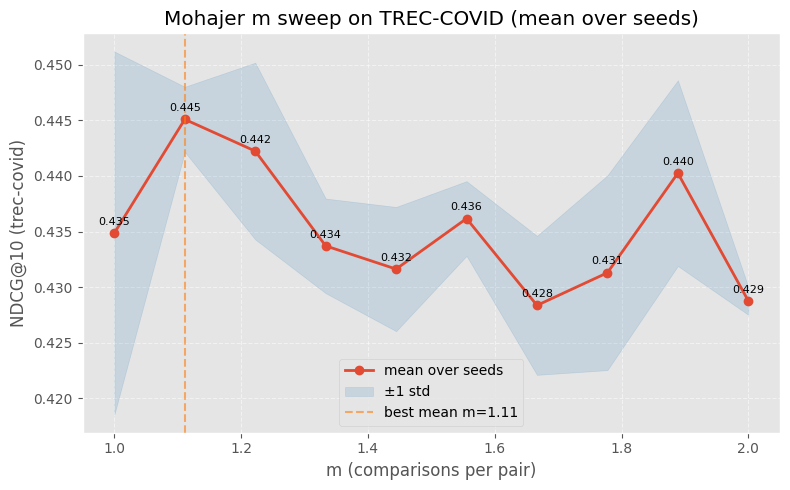

In [5]:
mean_by_m = m_sweep_df.groupby('m')['NDCG@10'].agg(['mean', 'std']).reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_by_m['m'], mean_by_m['mean'], marker='o', linewidth=2, label='mean over seeds')

# shaded band for +/- 1 std if available
if mean_by_m['std'].notna().any():
    lower = mean_by_m['mean'] - mean_by_m['std']
    upper = mean_by_m['mean'] + mean_by_m['std']
    ax.fill_between(mean_by_m['m'], lower, upper, color='tab:blue', alpha=0.15, label='±1 std')

for _, row in mean_by_m.iterrows():
    ax.annotate(f"{row['mean']:.3f}", xy=(row['m'], row['mean']), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=8)

best_mean_row = mean_by_m.loc[mean_by_m['mean'].idxmax()]
ax.axvline(best_mean_row['m'], color='tab:orange', linestyle='--', alpha=0.6, label=f"best mean m={best_mean_row['m']:.2f}")

ax.set_xlabel('m (comparisons per pair)')
ax.set_ylabel('NDCG@10 (trec-covid)')
ax.set_title('Mohajer m sweep on TREC-COVID (mean over seeds)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


- Reuse the cached rerank matrix under `data/external/reranking-matrices` and the BEIR dataset cache under `data/external/beir`.
- Adjust `M_VALUES` to try different sampling budgets or add finer granularity.
- Keep the seed fixed when you want to compare only the effect of `m`; change it to check robustness across random draws.
